Student 2: Logistic Regression
Notebook must include:
1. Dataset loading and cleaning.
2. EDA relevant to logistic regression assumptions.
3. Logistic regression model code.
4. Model performance evidence.
5. Coefficient or odds-ratio interpretation in markdown.
6. At least one limitation of using logistic regression for churn.


## Dataset loading

In [1]:

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## EDA

In [3]:
#EDA

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## DATA PROCESSING

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df['InternetService'].value_counts()


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [8]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [9]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [10]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

## Categorical Features vs. Churn

Before trusting the model's coefficients, look at the raw churn rate for each category. This gives actual numbers to check the coefficient story against.

In [11]:
cat_features = ['Contract', 'InternetService', 'OnlineSecurity', 'PhoneService']

for col in cat_features:
    print(f"Churn rate by {col}:")
    print(pd.crosstab(df[col], df['Churn'], normalize='index').round(3))
    print()

Churn rate by Contract:
Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028

Churn rate by InternetService:
Churn               No    Yes
InternetService              
DSL              0.810  0.190
Fiber optic      0.581  0.419
No               0.926  0.074

Churn rate by OnlineSecurity:
Churn                   No    Yes
OnlineSecurity                   
No                   0.582  0.418
No internet service  0.926  0.074
Yes                  0.854  0.146

Churn rate by PhoneService:
Churn            No    Yes
PhoneService              
No            0.751  0.249
Yes           0.733  0.267



Contract, InternetService, and OnlineSecurity all show large, consistent gaps in raw churn rate (e.g. 42.7% for month-to-month vs. 2.8% for two-year contracts), which matches the direction and size of their coefficients later in the model.

PhoneService is different: the raw churn rate is almost identical whether a customer has phone service or not (26.7% vs. 24.9%). In the fitted model below, its coefficient is also close to zero (-0.030, odds ratio 0.971), which is consistent — but this is worth double-checking, not trusting by default, because PhoneService is perfectly collinear with `MultipleLines_No phone service` (confirmed by the infinite VIF values above): every customer with `PhoneService = No` has `MultipleLines = No phone service` and vice versa. With two perfectly duplicate columns, the model could have put the (small) effect on either one; the split between their coefficients is not something the data can actually identify, so neither should be read as a standalone effect.

In [12]:

df_encode = df.copy()
df_encode = df_encode.drop(columns=['customerID'])

binary_cols = [
    'Churn',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df_encode[col] = df_encode[col].map({
        'No': 0,
        'Yes': 1
    })

df_encode['gender'] = df_encode['gender'].map({
    'Female': 0,
    'Male': 1
})


categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df_encode = pd.get_dummies(
    df_encode,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [13]:
df_encode['TotalCharges'] = pd.to_numeric(
    df_encode['TotalCharges'],
    errors='coerce'
)

In [14]:
df_encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [15]:
#print(df_encode.isna().sum())

In [16]:
df_encode = df_encode.dropna(subset=['TotalCharges'])

## Logestic Regression 

In [17]:
# Check Multicollinearity
corr = df_encode[
    ['tenure', 'MonthlyCharges', 'TotalCharges']
].corr()

print(corr)

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.246862      0.825880
MonthlyCharges  0.246862        1.000000      0.651065
TotalCharges    0.825880        0.651065      1.000000


TotalCharges is highly correlated with other numerical variables

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF tells us how much each feature's own variance is inflated
# by its correlation with the other features
X_vif = add_constant(df_encode.drop(columns=['Churn']))

vif_values = []
for i in range(X_vif.shape[1]):
    vif_values.append(variance_inflation_factor(X_vif.values, i))

vif_df = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": vif_values
})

vif_df = vif_df[vif_df["Feature"] != "const"]
vif_df = vif_df.sort_values("VIF", ascending=False)
vif_df.round(2)

/Users/shellyy/miniforge3/envs/jupyter_env/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/shellyy/miniforge3/envs/jupyter_env/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
16,OnlineBackup_No internet service,inf
10,MultipleLines_No phone service,inf
20,TechSupport_No internet service,inf
18,DeviceProtection_No internet service,inf
24,StreamingMovies_No internet service,inf
14,OnlineSecurity_No internet service,inf
13,InternetService_No,inf
22,StreamingTV_No internet service,inf
6,PhoneService,inf
8,MonthlyCharges,866.09


TotalCharges has a VIF of about 10.8, right at the common rule-of-thumb cutoff of 10, matching the correlation seen above (0.83 with tenure, 0.65 with MonthlyCharges). It is largely redundant: TotalCharges is roughly tenure × MonthlyCharges, so the model already gets most of that information from the other two features.

MonthlyCharges itself has a far more extreme VIF of about 866, and InternetService_Fiber optic is at 148.5. These three numeric/near-numeric features (tenure, MonthlyCharges, TotalCharges) are tangled together, which is why their coefficients turn out large, opposite-signed, and counterintuitive once the model is fit correctly below. That instability is a symptom of this multicollinearity, not evidence of a real effect. Dropping TotalCharges would remove the most redundant of the three and should make the remaining coefficients more stable.

A few dummy columns show infinite VIF. This is a separate, structural issue: customers with no internet service get the same "No internet service" label repeated across six different columns (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies), so those columns are perfect duplicates of each other. Their individual coefficients are not reliable on their own.

### Checking the Linearity Assumption for Tenure

Logistic regression assumes each numeric feature has a straight-line relationship with the log-odds of churn. We can check this for `tenure` by binning it into groups, computing the actual churn rate in each bin, and converting that rate to log-odds. If the assumption holds, the points below should roughly follow a straight line.

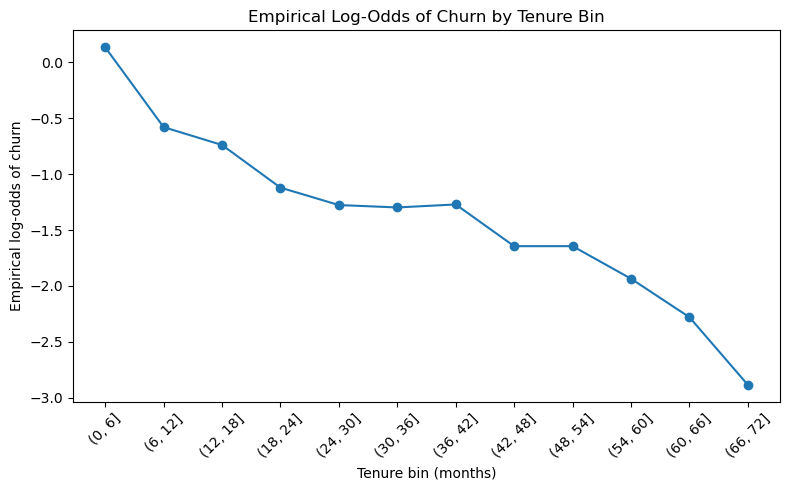

In [19]:
# Bin tenure into 6-month groups
tenure_bins = list(range(0, 78, 6))
df_encode['tenure_bin'] = pd.cut(df_encode['tenure'], bins=tenure_bins)

# Actual churn rate per bin
tenure_churn_rate = df_encode.groupby('tenure_bin', observed=True)['Churn'].mean()

# Convert churn rate to log-odds: log(p / (1 - p))
tenure_log_odds = np.log(tenure_churn_rate / (1 - tenure_churn_rate))

plt.figure(figsize=(8, 5))
plt.plot(tenure_log_odds.index.astype(str), tenure_log_odds.values, marker='o')
plt.xlabel('Tenure bin (months)')
plt.ylabel('Empirical log-odds of churn')
plt.title('Empirical Log-Odds of Churn by Tenure Bin')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_encode = df_encode.drop(columns=['tenure_bin'])

The empirical log-odds are not a straight line. They drop sharply over the first year (from about 0.13 at 0-6 months to about -0.74 at 12-18 months), then flatten out through the middle tenure range (roughly -1.1 to -1.3 between 18 and 42 months), before declining further for the longest-tenured customers. A single logistic regression slope for `tenure` averages over this curve, it will underestimate the risk drop in year one and overstate it in the flat middle years. This is a concrete example of the linearity limitation already noted below.

In [20]:
X = df_encode.drop(columns=['Churn'])
y = df_encode['Churn']

# Split train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale all features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
# Predictions
lr_pred = model.predict(X_test_scaled)
lr_prob = model.predict_proba(X_test_scaled)[:, 1]

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score)

import matplotlib.pyplot as plt

print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.3f}")
print(f"Precision: {precision_score(y_test, lr_pred):.3f}")
print(f"Recall:    {recall_score(y_test, lr_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, lr_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_prob):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Accuracy:  0.787
Precision: 0.621
Recall:    0.516
F1 Score:  0.564
ROC-AUC:   0.832

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Model performance 

In [24]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
})

coef_df = coef_df.sort_values("Odds_Ratio",ascending=False
)

coef_df.round(3)

,Feature,Coefficient,Odds_Ratio
8,TotalCharges,0.695,2.003
11,InternetService_Fiber optic,0.651,1.917
24,StreamingMovies_Yes,0.222,1.249
22,StreamingTV_Yes,0.213,1.237
10,MultipleLines_Yes,0.161,1.174
6,PaperlessBilling,0.135,1.144
28,PaymentMethod_Electronic check,0.124,1.132
1,SeniorCitizen,0.095,1.100
18,DeviceProtection_Yes,0.040,1.041
9,MultipleLines_No phone service,0.030,1.030


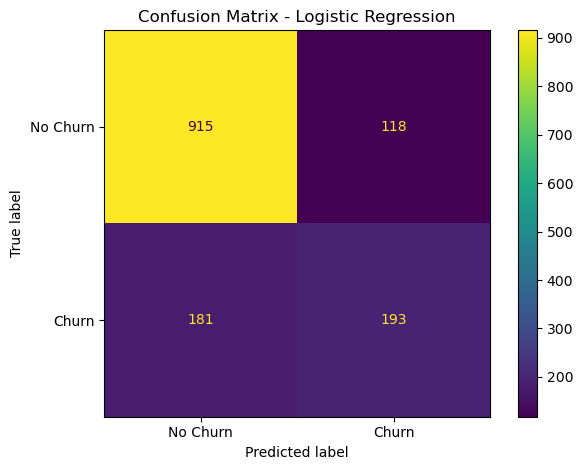

In [25]:
# Confusion Matrix:
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay)

cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Churn', 'Churn'])

disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()


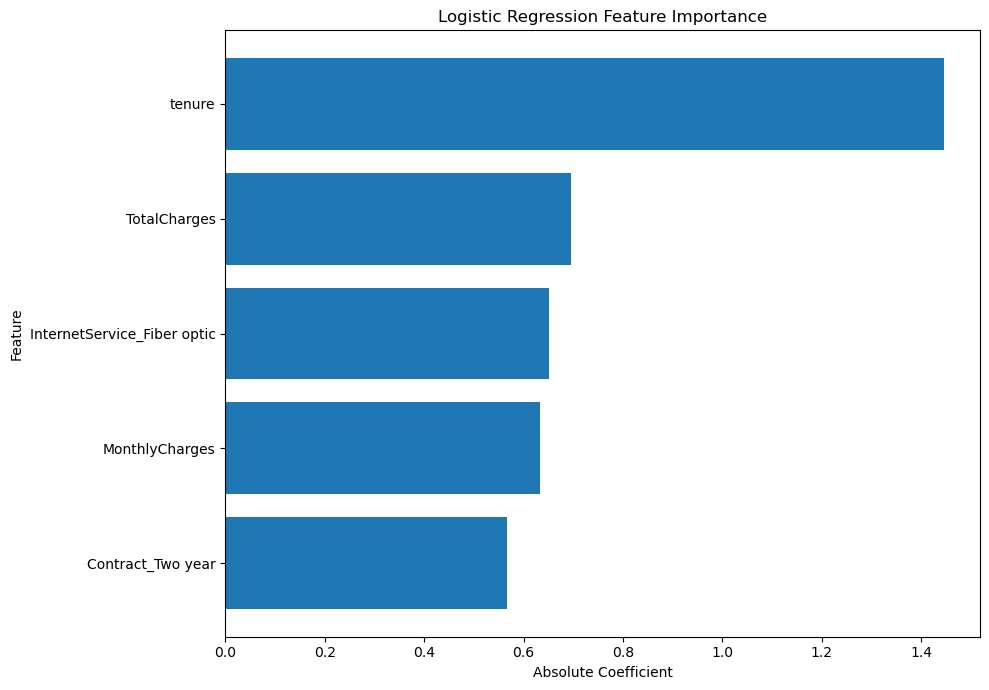

In [26]:
# Feature importance based on absolute logistic regression coefficients
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

importance_df['Importance'] = abs(importance_df['Coefficient'])
importance_df = importance_df.sort_values('Importance', ascending=False).head(5)

# Plot
plt.figure(figsize=(10, 7))

plt.barh(importance_df['Feature'], importance_df['Importance']
)

plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.title('Logistic Regression Feature Importance')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Coefficient and Odds-Ratio Interpretation

- **Tenure:** coefficient -1.446, odds ratio 0.236. This is now the strongest predictor in the model holding other predictors constant, a one-standard-deviation increase in tenure (about 25 months) is associated with roughly 76% lower odds of churn. This matches the empirical log-odds plot above, which shows churn risk dropping steeply as tenure increases.

- **TotalCharges and MonthlyCharges:** these two swing to large, opposite-signed, and counterintuitive coefficients (TotalCharges: +0.695, odds ratio 2.00; MonthlyCharges: -0.633, odds ratio 0.53). Taken at face value this would say "customers who have paid more in total are more likely to churn, but customers with a higher monthly bill are less likely to churn" which doesn't make business sense. The VIF check above flags exactly this: tenure, MonthlyCharges, and TotalCharges are highly collinear (TotalCharges VIF ≈ 10.8, MonthlyCharges VIF ≈ 866), so these two coefficients are not reliable individually and should not be interpreted on their own.

- **Fiber-optic internet:** coefficient 0.651, odds ratio 1.92. Holding other predictors constant, fiber-optic customers have about 92% higher odds of churn than the reference internet category. This lines up with the raw churn rates above (41.9% fiber vs. 19.0% DSL vs. 7.4% no internet).

- **Contract length:** two-year contracts (coefficient -0.567, odds ratio 0.567) and one-year contracts (coefficient -0.315, odds ratio 0.730) both have lower odds of churn than month-to-month, consistent with the large raw-rate gap seen earlier (42.7% vs. 11.3% vs. 2.8%).

- **Online security / tech support:** customers with online security (coefficient -0.156, odds ratio 0.856) or tech support (coefficient -0.143, odds ratio 0.866) have modestly lower odds of churn, again consistent with the raw rate comparison (41.8% vs. 14.6% churn for online security).

Tenure and contract length are the most trustworthy signals of retention here. The TotalCharges/MonthlyCharges result is a good illustration of why the VIF check mattered: once collinear numeric features are properly scaled, their coefficients can become large and individually misleading even though the model's overall predictive performance barely changes. As before, these are associations estimated by the model, not causal effects.

In [27]:
df_encode["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### Limitation 

1. Logestic regression assumes that continuous predictors have an approximately linear relationship with the log-odds of churn. Customer behavior
may contain nonlinear patterns or interactions that are not captured by the model unless they are explicitly included.

2. Churn is imbalanced with fewer customers belonging to the churn class. As a result, the default 0.5 classification threshold may favor the majority non-churn class and fail to identify some customers who actually churn. For this reason, recall, F1-score, and ROC-AUC are considered alongside accuracy.

## Next Step: Refit Without TotalCharges

The VIF check above flagged TotalCharges (VIF ≈ 10.8) as redundant with tenure and MonthlyCharges, and linked it to the odd, opposite-signed coefficients those two features got in the main model. The main model above keeps TotalCharges in, to stay comparable with the other models in this project, which also kept it. As a next step, this section refits the same model without TotalCharges to check whether dropping it actually helps.

In [28]:
# Same pipeline as the main model, just without TotalCharges
X_no_tc = df_encode.drop(columns=['Churn', 'TotalCharges'])
y_no_tc = df_encode['Churn']

X_train_nt, X_test_nt, y_train_nt, y_test_nt = train_test_split(
    X_no_tc, y_no_tc, test_size=0.2, random_state=42
)

scaler_nt = StandardScaler()
X_train_nt_scaled = scaler_nt.fit_transform(X_train_nt)
X_test_nt_scaled = scaler_nt.transform(X_test_nt)

model_nt = LogisticRegression(max_iter=1000)
model_nt.fit(X_train_nt_scaled, y_train_nt)

nt_pred = model_nt.predict(X_test_nt_scaled)
nt_prob = model_nt.predict_proba(X_test_nt_scaled)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test_nt, nt_pred):.3f}")
print(f"Precision: {precision_score(y_test_nt, nt_pred):.3f}")
print(f"Recall:    {recall_score(y_test_nt, nt_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test_nt, nt_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_nt, nt_prob):.3f}")

Accuracy:  0.793
Precision: 0.633
Recall:    0.527
F1 Score:  0.575
ROC-AUC:   0.830


In [29]:
coef_df_nt = pd.DataFrame({
    "Feature": X_train_nt.columns,
    "Coefficient": model_nt.coef_[0],
    "Odds_Ratio": np.exp(model_nt.coef_[0])
})

coef_df_nt = coef_df_nt.sort_values("Odds_Ratio", ascending=False)
coef_df_nt.round(3)

,Feature,Coefficient,Odds_Ratio
10,InternetService_Fiber optic,0.678,1.969
23,StreamingMovies_Yes,0.242,1.274
21,StreamingTV_Yes,0.233,1.262
9,MultipleLines_Yes,0.178,1.195
6,PaperlessBilling,0.132,1.141
27,PaymentMethod_Electronic check,0.126,1.135
1,SeniorCitizen,0.096,1.101
17,DeviceProtection_Yes,0.055,1.056
2,Partner,0.026,1.026
8,MultipleLines_No phone service,0.021,1.021


Dropping TotalCharges barely changes predictive performance (accuracy 0.793 vs. 0.787, ROC-AUC 0.830 vs. 0.832 in the main model), so it wasn't adding much unique information. What does change is the numeric coefficients: tenure (-0.850, odds ratio 0.427) and MonthlyCharges (-0.517, odds ratio 0.596) are now both negative and reasonably sized, instead of the wild, opposite-signed swing seen in the main model (tenure -1.446 / TotalCharges +0.695). 

This supports the recommendation from the VIF check: TotalCharges was mostly redundant, and removing it stabilizes the coefficients without costing predictive performance. It is kept as a separate next step here, rather than replacing the main model above, so the main analysis stays directly comparable to the other models in this project that also kept TotalCharges.